# Get Cobra results
This notebook presents cobrapy seed searching from media by minimizing component.

> Corresponding function into cobrapy:
>
>```
>  cobra.medium.minimal_medium(model, max_growth, minimize_components=nb_solutions)
>```


To run correctly this notebook and have the same results as the paper, you must first download the raw results: [https://doi.org/10.57745/OS1JND](https://doi.org/10.57745/OS1JND)

This notebook is written with the hierarchy of downloaded files, if you want to try it with the test form the run notebooks, it is needed to first restructure your data to match the hierarchy of downloaded files.

We suppose here that the downloaded files are in a directory named "analyses", this directory path can be changed to your directory path where the data are saved.

## Requirements
Module *pandas*, *numpy*, *seaborn* and *scipy* are needed

In [ ]:
!pip install pandas

In [ ]:
!pip install numpy

In [ ]:
!pip install seaborn

In [ ]:
!pip install scipy

# Variable to change (if wanted)

In [1]:
analyse_dir = "../../analyses"
data_dir = f"{analyse_dir}/data"

# Directories to create for R analyses and plots
timer_tables_dir = f"{analyse_dir}/results/timer_cobra_s2lp/tables"
timers_plot_dir = f"{analyse_dir}/results/timer_cobra_s2lp/plots"
gcd1_timer_tables=f"{analyse_dir}/results/timer_one_sol/tables/Target.tsv"

# Initialisation and functions

In [2]:
import os
import pandas as pd
import seaborn as sns
import math
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import numpy as np

In [3]:
%load_ext rpy2.ipython

In [4]:
result_dir = os.path.join(analyse_dir, "results")

s2lp_results_gcd_ten_sol = os.path.join(result_dir, "s2lp_gcd_10_solutions")
s2lp_scope_dir = os.path.join(result_dir, "scopes_s2lp_gcd_10_solutions")
s2lp_supp_data = os.path.join(result_dir, "supp_data", "s2lp_gcd_10_solutions_supp_data.tsv")

cobra_1_dir = os.path.join(result_dir, "cobra_1")
cobra_1_supp_data_file=os.path.join(cobra_1_dir, "cobra_supp_data.tsv")


cobra_10_dir = os.path.join(result_dir, "cobra_10")
cobra_10_results_dir = os.path.join(cobra_10_dir, "seeds_results")
cobra_10_scope_dir = os.path.join(cobra_10_dir, "scopes")
cobra_10_supp_data_file=os.path.join(cobra_10_dir, "cobra_supp_data.tsv")

sbml_dir = f'{data_dir}/bigg/sbml'

In [5]:
if not os.path.isdir(timer_tables_dir):
    os.makedirs(timer_tables_dir)

if not os.path.isdir(timers_plot_dir):
    os.makedirs(timers_plot_dir)

## TIMERS

In [6]:
def get_cumul(file,step):
    timer = pd.read_csv(file, sep='\t', lineterminator='\n')
    timer=timer.drop(["Unnamed: 0"], axis=1)
    timer['steps_time'] = timer.apply(lambda row: int(math.ceil(row.time / step)) * step, axis=1)
    df_count = timer.groupby('steps_time').count()
    df_count["sum"]=0
    sum=0
    for id, row in df_count.iterrows():
        sum += row["time"]
        df_count.loc[[id],["sum"]] = sum

    return df_count

In [7]:
def get_cobra_timer(file, column_name):
    timer = pd.read_csv(file, sep='\t', lineterminator='\n')
    timer=timer.drop(["Unnamed: 0"], axis=1)
    timer=timer.drop(["size"], axis=1)
    timer=timer.rename(columns={"time": column_name})
    return timer

In [8]:
def get_separate_data(table):
    table["solver_type"] = table["solver_type"].str.replace('REASONING  GUESS-CHECK-DIVERSITY', 'REASONING GUESS-CHECK DIVERSITY')
    table["solver_type"] = table["solver_type"].str.replace('REASONING  GUESS-CHECK', 'REASONING GUESS-CHECK')
    table["solver_type"] = table["solver_type"].str.replace('REASONING  FILTER', 'REASONING FILTER')
    
    # CLASSIC
    table_reasoning = table[table["solver_type"]=="REASONING"]
    
    # FILTER
    table_filter = table[table["solver_type"]=="REASONING FILTER"]

    # GUESS_CHECK
    table_gc = table[table["solver_type"]=="REASONING GUESS-CHECK"]

    # GUESS_CHECK_DIV
    table_gcd = table[table["solver_type"]=="REASONING GUESS-CHECK DIVERSITY"]

    return table_reasoning, table_filter, table_gc, table_gcd

In [9]:
def get_timers(file_path, mode):
    table_all = pd.read_csv(file_path, sep='\t', lineterminator='\n')
    table_all=table_all.fillna(-50)
    table_all.loc[table_all["minimize"] == "unsat", "minimize"] = -100
    table_all.loc[table_all["minimize_opti"] == "unsat", "minimize_opti"] = -100
    table_all.loc[table_all["submin"] == "unsat", "submin"] = -100
    table_all.loc[table_all["minimize"] == "Time out", "minimize"] = -200
    table_all.loc[table_all["minimize"] == "time out", "minimize"] = -200
    table_all.loc[table_all["minimize_opti"] == "Time out", "minimize_opti"] = -200
    table_all.loc[table_all["minimize_opti"] == "time out", "minimize_opti"] = -200
    table_all.loc[table_all["submin"] == "Time out", "submin"] = -200
    table_all.loc[table_all["submin"] == "time out", "submin"] = -200
    table_all['minimize'] = table_all['minimize'].astype('float')
    table_all['minimize_opti'] = table_all['minimize_opti'].astype('float')
    table_all['submin'] = table_all['submin'].astype('float')

    timers_all= table_all.loc[table_all["type_data"] == "Solving (sec)"]
    # No accumulation mode
    timers_all = timers_all[timers_all['accumulation']==False]

    if mode == "full":
        return timers_all[timers_all["search_mode"]=="Full network"]
    elif mode == "target":
        return timers_all[timers_all["search_mode"]=="Target"]
    else:
        return timers_all

In [10]:
def convert_timers_table(table:pd.DataFrame, optim, list_all_species, dict_species):
    column_conversion = {"REASONING":"Reasoning",
                         "REASONING FILTER":"Filter",
                         "REASONING GUESS-CHECK":'Guess-Check',
                         "REASONING GUESS-CHECK-DIVERSITY":'Guess-Check-div'}

    
    set_complete = set(list_all_species)
    set_gcd = set(dict_species["gcd"])
    
    diff_gcd = set_complete.difference(set_gcd) 
    new_table=pd.DataFrame(columns=['network', 'Reasoning','Filter',
                                'Guess-Check', 'Guess-Check-div'])
    new_table = new_table.set_index('network')

    for row in table.iterrows():
        network = row[0]
        if not new_table.empty:
            if network in new_table.index:
                new_table.loc[network, column_conversion[row[1]['mode']]]=row[1][optim]
            else:
                new_table = add_row(new_table, row, optim, column_conversion)
        else:
            new_table = add_row(new_table, row, optim, column_conversion)

    for net in diff_gcd:
        new_table.loc[net, ["Guess-Check-div"]]=-1000
    return new_table.reset_index()


def add_row(new_table,row, optim, column_conversion):
    network = row[1]['network']
    current = pd.DataFrame(data=[[network, row[1][optim]]], columns=['network', column_conversion[row[1]['mode']]])
    current = current.set_index('network')
    new_table = new_table.combine_first(current)
    return new_table

In [11]:
def create_table_plot(table,column_name):
    new_table = table.groupby(['species'])[column_name].agg('count').reset_index()
    new_table=new_table.rename(columns={column_name: "Total_flux"})
    new_true = table[table[column_name]==True].groupby(['species'])[column_name].agg('count').reset_index()
    new_true=new_true.rename(columns={column_name: "True_flux"})
    new_false = table[table[column_name]==False].groupby(['species'])[column_name].agg('count').reset_index()
    new_false=new_false.rename(columns={column_name: "False_flux"})
    new_table=pd.merge(new_table,new_true, how='left', on=['species'])
    new_table=pd.merge(new_table,new_false, how='left', on=['species'])
    new_table=new_table.fillna(0)
    new_table=new_table.fillna(0)
    new_table['True_flux']=new_table['True_flux'].astype(int)
    new_table['False_flux']=new_table['False_flux'].astype(int)
    return new_table

In [12]:
def get_list_species(table):
    labels = table['species'].tolist()
    set_labels = set(labels)
    return set_labels

In [13]:
def get_all_species():
    species_files = os.listdir(sbml_dir)
    species = [sub.replace('.xml', '') for sub in species_files]
    return species

## Fluxes

In [14]:
def get_fluxes(directory:str, mode:str, optim:str=None):
    flux_all=pd.DataFrame(columns=['species', 'biomass_reaction', 'solver_type', 'search_mode',
                                     'search_type', 'accumulation', 'model', 'size', 'lp_flux', 'cobra_flux_init',
                                     'cobra_flux_no_import', 'cobra_flux_seeds', 'cobra_flux_demands',
                                     'has_flux', 'has_flux_seeds', 'has_flux_demands', 'timer'])
    flux_all['accumulation'] = flux_all['accumulation'].astype('bool')
    flux_all['has_flux'] = flux_all['has_flux'].astype('bool')
    flux_all['has_flux_seeds'] = flux_all['has_flux_seeds'].astype('bool')
    flux_all['has_flux_demands'] = flux_all['has_flux_demands'].astype('bool')

    for dirpath, _, filenames in os.walk(directory):
        for filename in [f for f in filenames if (f.endswith("_fluxes.tsv") or f.endswith("_fluxes_from_result.tsv"))]:
            # By default in this notebook we want the no accumulation mode for seed2lp results
            # and only GuessCheck diversity
            if  "_no_accu_" in filename \
                and   ((mode == "full" and "_fn_" in filename) \
                    or (mode == "target" and "_tgt_" in filename)) \
                    and  "_gcd_" in filename:
                file_path=os.path.join(dirpath, filename)
                current_df = pd.read_csv(file_path, sep='\t', lineterminator='\n')
                current_df['accumulation'] = current_df['accumulation'].astype('bool')
                current_df['has_flux'] = current_df['has_flux'].astype('bool')
                current_df['has_flux_seeds'] = current_df['has_flux_seeds'].astype('bool')
                current_df['has_flux_demands'] = current_df['has_flux_demands'].astype('bool')
                flux_all=pd.concat([flux_all if not flux_all.empty else None, current_df], ignore_index=True)
    
    if optim=="submin":
        return flux_all[flux_all["search_mode"]=="Subset Minimal"]
    elif optim=="min":
        return flux_all[flux_all["search_mode"]=="Minimize"]
    else:
        return flux_all

In [15]:
def get_all_same_validation_fba(table,type):
    count=0
    total=0
    for _,line in table.iterrows():
        if line[type] == line["Total_flux"]:
            count += 1
            total += 1
        else:
            total += 1
    
    return total, count

In [16]:
def create_one_plot(s2lp, labels, s2lp_scope, cobra_scope):
    plt.style.use("seaborn-v0_8-colorblind")
    
    _, s2lp_true_count = get_all_same_validation_fba(s2lp, "True_flux")
    _, s2lp_false_count = get_all_same_validation_fba(s2lp,"False_flux")
    s2lp_missing_networks = 107 - (s2lp_true_count + s2lp_false_count)

    # cobra is designed to find solution with flux 
    cobra_true_count = len(cobra_scope.groupby(['species']))
    cobra_false_count = 0
    cobra_missing_networks = 107 - (cobra_true_count + cobra_false_count)


   #Get Biomass into scope info
    s2lp_scope_mean_by_species = s2lp_scope.groupby(['species'])['percentage_similar_biomass'].mean()
    cobra_scope_mean_by_species = cobra_scope.groupby(['species'])['percentage_similar_biomass'].mean()

    s2lp_true_scope_count = s2lp_scope_mean_by_species.value_counts()[100]
    s2lp_true_no_scope_count = s2lp_true_count - s2lp_true_scope_count

    try:
        cobra_true_scope_count = cobra_scope_mean_by_species.value_counts()[100]
    except:
        cobra_true_scope_count = 0
    cobra_true_no_scope_count = cobra_true_count - cobra_true_scope_count


    # create seaprate value plot
    s2lp_tab=pd.DataFrame([[s2lp_true_scope_count, s2lp_true_no_scope_count, s2lp_false_count, s2lp_missing_networks]], 
                          columns=["all_true_scope","all_true_no_scope","all_false","missing"])
    s2lp_tab=s2lp_tab.assign(Tool=labels[0])

    cobra_tab=pd.DataFrame([[cobra_true_scope_count, cobra_true_no_scope_count, cobra_false_count, cobra_missing_networks]],
                              columns=["all_true_scope","all_true_no_scope","all_false","missing"])
    cobra_tab=cobra_tab.assign(Tool=labels[1])
    concat_table = pd.concat([cobra_tab,s2lp_tab])


    plt.figure(figsize=(1,3))
    sns.set_theme(font_scale = 1.5)
    fig, ax = plt.subplots()
    fig.tight_layout()
    groups = concat_table['Tool']
    ax.bar(groups, concat_table["all_true_scope"], color='#1e73be',label='flux & scope', width=0.2)
    ax.bar(groups, concat_table["all_true_no_scope"], bottom = concat_table["all_true_scope"], 
           color='#945cb4', label='flux', width=0.2)
    ax.bar(groups, concat_table["all_false"], bottom = concat_table["all_true_scope"]+concat_table["all_true_no_scope"], 
           color='#ef3340', label='no flux', width=0.2)
    ax.bar(groups, concat_table["missing"], bottom =  concat_table["all_true_scope"]+concat_table["all_true_no_scope"]+concat_table["all_false"], 
           color='black', label='no solution', width=0.2)
    
    plt.ylabel('Number of GSMNs', fontsize=25)
    plt.xlabel('Tools', fontsize=25)
    plt.xticks(size=22)
    plt.yticks(size=22)
    #sns.despine(bottom=True)
    plt.tick_params(bottom=False, left=True)
    plt.legend(frameon=True,  loc='center right', borderaxespad=-10)

    pict_dir="/home/cghassem/Projets/seed-2-lp/picture/"
    plt.savefig(pict_dir+'cobra_flux.pdf', bbox_inches='tight')
    return 

## SCOPES

In [17]:
def get_scopes(directory:str, mode:str, optim:str=None):
    scope_all=pd.DataFrame(columns=['species','run','mode','optim', 'accu','model',
                                'is_equal_union_species', 'missing', 'percentage_missing',
                                'is_biomass_included', 'missing_biomass', 'percentage_missing_biomass',
                                'is_exchange_included', 'missing_exchange', 'percentage_missing_exchange',
                                'is_seed_included_to_exchange', 'missing_seed_into_exchange', 'percentage_missing_seed_into_exchange',
                                'is_exchange_included_to_seed', 'missing_exchange_into_seed', 'percentage_missing_exchange_into_seeds'])
    if mode == "netseed":
        prefix="netseed"
    else:
        prefix="scope"
    for species in os.listdir(directory):
        if mode == "cobrapy":
            file_path = os.path.join(directory, species, "scope", "cobrapy", "cobrapy", "other", "no_accu", f"{species}_cobrapy_compare.tsv")
        else:
            file_path = os.path.join(directory, species, f"{species}_{prefix}_compare.tsv")
        if os.path.exists(file_path):
            current_df = pd.read_csv(file_path, sep='\t', lineterminator='\n')
            current_df['is_equal_union_species'] = current_df['is_equal_union_species'].map({True: 'True', False: 'False'})
            current_df['is_biomass_included'] = current_df['is_biomass_included'].map({True: 'True', False: 'False'})
            current_df['is_exchange_included'] = current_df['is_exchange_included'].map({True: 'True', False: 'False'})
            current_df['is_seed_included_to_exchange'] = current_df['is_seed_included_to_exchange'].map({True: 'True', False: 'False'})
            current_df['is_exchange_included_to_seed'] = current_df['is_exchange_included_to_seed'].map({True: 'True', False: 'False'})
            current_df["percentage_similar"]=100-current_df["percentage_missing"]
            current_df["percentage_similar_biomass"]=100-current_df["percentage_missing_biomass"]
            current_df["percentage_similar_exchange"]=100-current_df["percentage_missing_exchange"]
            current_df["percentage_similar_seed_into_exchange"]=100-current_df["percentage_missing_seed_into_exchange"]
            current_df["percentage_similar_exchange_into_seeds"]=100-current_df["percentage_missing_exchange_into_seeds"]
            scope_all=pd.concat([scope_all, current_df], ignore_index=True)
    # in this notebook we use only Guess-Check-Diversity and only the non accumulation mode for Seed2LP
    if mode == "full":
        scope_all = scope_all[scope_all["mode"]=="reasoning_guess_check_diversity"]
        scope_all = scope_all[scope_all["accu"]==False]
        scope = scope_all[scope_all["run"]=="full"]
    elif mode == "target":
        scope_all = scope_all[scope_all["mode"]=="reasoning_guess_check_diversity"]
        scope_all = scope_all[scope_all["accu"]==False]
        scope = scope_all[scope_all["run"]=="target"]
    else:
        scope = scope_all

    if optim=="submin":
        return scope[scope["optim"]=="subset_minimal"]
    elif optim=="min":
        return scope[scope["optim"]=="minimize"]
    else:
        return scope

In [18]:
def sub_cobra_within_45m(cobra_timer, scope_cobra, data_size_cobra):
    data_size_cobra = data_size_cobra.dropna()
    for _, val in cobra_timer.iterrows():
        if val["cobra_10"] > 2700:
            scope_cobra=scope_cobra[scope_cobra["species"]!=val["network"]]
            data_size_cobra=data_size_cobra[data_size_cobra["species"]!=val["network"]]

    return scope_cobra,data_size_cobra

In [19]:
def plot_compare(df1:pd.DataFrame, df2:pd.DataFrame, col, labels, y_label:str=""):
    np.set_printoptions(precision=3)
    plt.style.use("seaborn-v0_8-colorblind")


    nan_spec=df1[df1[col].isnull()]["species"]
    for nspe in nan_spec:
        df1=df1.drop(df1.loc[df1['species']==nspe].index)

    nan_spec=df2[df2[col].isnull()]["species"]
    for nspe in nan_spec:
        df2=df2.drop(df2.loc[df2['species']==nspe].index)

    del_spec=set(df2['species']) - set(df1['species'])
    for sp in del_spec:
        df2=df2.drop(df2.loc[df2['species']==sp].index)

    n = len(df1['species'].unique())
    
    df1=df1.assign(Tool=labels[0])
    df2=df2.assign(Tool=labels[1])
    
    concat_table = pd.concat([df1, df2])

    scope_tab = concat_table.groupby(['species','Tool'])[col].mean()
    scope_df=pd.DataFrame(scope_tab)
    scope_df=scope_df.reset_index()
    plt.figure(figsize=(3,4))
    sns.set_theme(font_scale = 1.5)


    df1_means= scope_df[scope_df['Tool']==labels[0]]
    df2_means= scope_df[scope_df['Tool']==labels[1]]
    df1_gen_mean=df1_means[col].mean()
    df2_gen_means=df2_means[col].mean()
    print(labels[0], " global mean: ",df1_gen_mean, "\t ", labels[1], "global mean: ", df2_gen_means)


    # KRUSKAL WALLIS TESTS
    # Get the p-value from Kruskall Wallis test
    if df1_gen_mean != df2_gen_means:
     kstat, p_value = kruskal(scope_df[scope_df["Tool"]==labels[1]][col], scope_df[scope_df["Tool"]==labels[0]][col])
    else:
        kstat, p_value = None, None

    sns.boxplot(data=scope_df, x="Tool", y=col, hue="Tool", fill=False, linewidth=1.5)
    plt.xlabel('')
    plt.ylabel(y_label)
    plt.title(f"kstat = {kstat}, p-value = {p_value}, n={n}")
    sns.despine(bottom=True)

    pict_dir="/home/cghassem/Projets/seed-2-lp/picture/"
    match col:
        case "percentage_similar_exchange_into_seeds":
            supp="exchange"
        case "percent":
            supp="size"
        case "percentage_similar_biomass":
            supp="biomass"
        case "percentage_similar":
            supp="full"

    plt.savefig(pict_dir+f'cobra_{supp}.pdf', bbox_inches='tight')

In [20]:
def get_sizes(flux_df:pd.DataFrame, nb_total_meta:pd.DataFrame):
    list_mean_size = flux_df.groupby(['species'])['size'].mean()
    mean_size_df = pd.DataFrame(list_mean_size)
    data_size_df = pd.concat([nb_total_meta, mean_size_df], axis=1)
    data_size_df["percent"]=data_size_df["size"] / data_size_df["number_metabolites"] *100
    data_size = pd.DataFrame(data_size_df["percent"])
    data_size=data_size.reset_index()
    data_size=data_size.rename(columns={"index": "species"})
    return data_size

In [21]:
def get_sizes_cobra(supp_data_file,  nb_total_meta:pd.DataFrame):
    table_all = pd.read_csv(supp_data_file, sep='\t', lineterminator='\n')
    # get value within 45 min
    table_all=table_all[table_all['time']<2700]
    table_all=table_all.set_index('network')
    data_size_df = pd.concat([nb_total_meta, table_all["size"]], axis=1)
    data_size_df["percent"]=data_size_df["size"] / data_size_df["number_metabolites"] *100
    data_size = pd.DataFrame(data_size_df["percent"])
    data_size=data_size.reset_index()
    data_size=data_size.rename(columns={"network": "species"})
    return data_size

In [22]:
def get_total_nb_meta(supp_data_file):
    table_all = pd.read_csv(supp_data_file, sep='\t', lineterminator='\n')
    union_all = table_all.loc[table_all["type_data"] == "Union"]
    num_metabolite = union_all.groupby(['network'])['number_metabolites'].first()
    return pd.DataFrame(num_metabolite)

In [23]:
def get_mean_std_deviation(table, tool):
    mean = table["Total_flux"].mean()
    std = table["Total_flux"].std()
    print(tool, f"mean = {mean}",  f"standard deviation = {std}")

In [24]:
def get_fba_ok_nb(table, tool):
    if tool == "Seed2LP":
        try:
            nb = len(table) - table['True_flux'].value_counts()[0]
        except:
            nb = len(table) 
    else:
        nb = len(table.species.unique())
    print(tool, f"Number of networks with solutions satisfying FBA = {nb}")

In [25]:
def get_fba_scope_ok_nb(table_scope, tool, has_table_flux=False, table_flux=None):
    if has_table_flux:
        table_no_flux = table_flux[table_flux['False_flux']!=0]
        for species in table_no_flux["species"]:
            table_scope=table_scope[table_scope["species"]!=species]
    scope_mean_by_species = table_scope.groupby(['species'])['percentage_similar_biomass'].mean()
    try :
        nb = scope_mean_by_species.value_counts()[100]
    except :
        nb = 0
    print(tool, f"Number of networks with solutions satisfying FBA and all biomass reactants reachable = {nb}")

In [26]:
def get_nb_networks_less_10_sol(scope_cobra_10, tool):
    num_sol_by_species = scope_cobra_10.species.value_counts()
    nb_less_10=0
    for _, nb in num_sol_by_species.items():
        if nb != 10 :
            nb_less_10 +=1
    print(tool, f"has {nb_less_10} networks having less than 10 solutions")

In [ ]:
def get_fba_ok_solutions(scope_table, tool):
    try:
        nb=scope_table['percentage_similar_biomass'].value_counts()[100]
        reach=round(scope_table['percentage_similar_biomass'].min(),2)
        type = "minimum"
    except:
        nb=0
        reach=round(scope_table['percentage_similar_biomass'].max(),2)
        type = "maximum"

    print(f"{tool}: {nb} solutions satisfying all biomass reactants reachable")
    print(f"{reach}% is the {type} biomass reacntants reachable")

# Get data

## TIMERS

In [27]:
nb_total_meta_df = get_total_nb_meta(s2lp_supp_data)

In [28]:
cobra_1_timer=get_cobra_timer(cobra_1_supp_data_file, 'cobra_1')

In [29]:
set(list(nb_total_meta_df.index)) - set(cobra_1_timer["network"])

{'RECON1'}

In [30]:
cobra_10_timer=get_cobra_timer(cobra_10_supp_data_file, 'cobra_10')

In [31]:
set(list(nb_total_meta_df.index)) - set(cobra_10_timer["network"])

{'RECON1', 'Recon3D'}

In [32]:
flux_T = get_fluxes(s2lp_results_gcd_ten_sol, "target")
T_reasoning, T_filter, T_gc, T_gcd = get_separate_data(flux_T)
T_gcd_tab=create_table_plot(T_gcd,'has_flux')
dict_species_T = {"gcd":get_list_species(T_gcd_tab)}
timers_T=get_timers(s2lp_supp_data, "target")
list_all_species = get_all_species()
timers_T_final = convert_timers_table(timers_T, "submin",  list_all_species, dict_species_T)

/tmp/ipykernel_227820/1264284479.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  flux_all=pd.concat([flux_all if not flux_all.empty else None, current_df], ignore_index=True)
/tmp/ipykernel_227820/1264284479.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  flux_all=pd.concat([flux_all if not flux_all.empty else None, current_df], ignore_index=True)
/tmp/ipykernel_227820/1264284479.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. I

In [33]:
cobra_1_timer.to_csv(f"{timer_tables_dir}/cobra_1.tsv", sep='\t')
cobra_10_timer.to_csv(f"{timer_tables_dir}/cobra_10.tsv", sep='\t')

In [34]:
data_size_cobra = get_sizes_cobra(cobra_10_supp_data_file, nb_total_meta_df)

## SCOPES

In [35]:
scope_cobra_10 = get_scopes(cobra_10_scope_dir, "cobrapy")

/tmp/ipykernel_227820/1999148358.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scope_all=pd.concat([scope_all, current_df], ignore_index=True)


In [36]:
sub_scope_cobra_10, sub_data_size_cobra = sub_cobra_within_45m(cobra_10_timer,scope_cobra_10, data_size_cobra)

In [37]:
scope_s2lp = get_scopes(s2lp_scope_dir, "target", "submin")

/tmp/ipykernel_227820/1999148358.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scope_all=pd.concat([scope_all, current_df], ignore_index=True)
/tmp/ipykernel_227820/1999148358.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scope_all=pd.concat([scope_all, current_df], ignore_index=True)
/tmp/ipykernel_227820/1999148358.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all

## Fluxes

In [39]:
flux_s2lp_TGT_submin = get_fluxes(s2lp_results_gcd_ten_sol, "target", "submin")

/tmp/ipykernel_227820/1264284479.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  flux_all=pd.concat([flux_all if not flux_all.empty else None, current_df], ignore_index=True)
/tmp/ipykernel_227820/1264284479.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  flux_all=pd.concat([flux_all if not flux_all.empty else None, current_df], ignore_index=True)
/tmp/ipykernel_227820/1264284479.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. I

In [40]:
flux_cobra = get_fluxes(s2lp_results_gcd_ten_sol, "target", "submin")

/tmp/ipykernel_227820/1264284479.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  flux_all=pd.concat([flux_all if not flux_all.empty else None, current_df], ignore_index=True)
/tmp/ipykernel_227820/1264284479.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  flux_all=pd.concat([flux_all if not flux_all.empty else None, current_df], ignore_index=True)
/tmp/ipykernel_227820/1264284479.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. I

In [41]:
s2lp_flux=create_table_plot(flux_s2lp_TGT_submin,'has_flux')
# Cobra is design to have flux for each solutions, no need to get it back

In [42]:
data_size_s2lp = get_sizes(flux_s2lp_TGT_submin, nb_total_meta_df)

Cobrapy gives minimal solution, either it finds 1 or 10 solutions, by species the size is the same

# PLOT

This part uses R to get the data tables from `timer_tables_dir` variable and write it in `timers_plot_dir` directory (set at the begining of the notebook in paragraphe  [Variable to change](#variable-to-change-if-wanted) ) 

In [43]:
%%R -i timer_tables_dir -i timers_plot_dir -i gcd1_timer_tables
library(reshape2)
library(data.table)
library(ggplot2)


# create output directory if it does not exist
if (!dir.exists(timers_plot_dir)) {
    dir.create(timers_plot_dir)
}

readfile <- function(filepath){
    # read the data
    data <- read.table(filepath, header = TRUE, sep = "\t") # , row.names = 1
    # get the name of the file, no extension
    file_id <- sub(pattern = "(.*)\\..*$", replacement = "\\1", basename(filepath))

    if (file_id == "gcd_10_tgt" || file_id == "Target"){
        data <- data[,c("network", "Guess.Check.div")]
        colnames(data) <- c("Network", "Time")
        # replace -200 with 2700
        data[data$Time == -200,] <- 2700
        # replace -100 with NA
        data[data$Time == -1000,] <- NA
        data$Group <-"Seed2LP Guess&Check Diversity"
        return(data)
    }
    else{
        colnames(data) <- c("num", "Network", "Time")
        # replace -200 with 2700
        data[data$Time == -200,] <- 2700
        # drop cobra inferences that lasted more than 45 min because such a time limit was set-up for seed2lp
        data[data$Time > 2700,] <- NA
        # drop a column
        data <- data[,c("Network", "Time")]
        # add group
        data$Group <- "Cobrapy"
        return(data)
    }
}


cobra1 <- readfile(paste(timer_tables_dir, "/cobra_1.tsv", sep = ""))
gcd_1  <- readfile(gcd1_timer_tables)
cobra10 <- readfile(paste(timer_tables_dir, "/cobra_10.tsv", sep = ""))
gcd_10 <- readfile(paste(timer_tables_dir, "/gcd_10_tgt.tsv", sep = ""))

all_1 <- rbind(cobra1, gcd_1)
all_10 <- rbind(cobra10, gcd_10)


# plot the data
p1 = ggplot(all_1, aes(x = Time, color = Group)) +
    stat_bin(data = subset(all_1, Group == "Cobrapy"), aes(y = cumsum(..count..)), geom = "step") +
    stat_bin(data = subset(all_1, Group == "Seed2LP Guess&Check Diversity"), aes(y = cumsum(..count..)), geom = "step") +
    # style the plot
    theme_bw() +
    labs(title = "Cobrapy vs Seed2LP (1 solution)", x = "Time", y = "Cumulative count of GSMNs with solutions", colour = "Solving mode") +
    # increase font size
    theme(text = element_text(size = 15))

# save the plot
ggsave(paste0(timers_plot_dir, "/", "cobra_gcd_1", ".pdf"), plot = p1, width = 10, height = 7)

# plot the data
p2 = ggplot(all_10, aes(x = Time, color = Group)) +
    stat_bin(data = subset(all_10, Group == "Cobrapy"), aes(y = cumsum(..count..)), geom = "step") +
    stat_bin(data = subset(all_10, Group == "Seed2LP Guess&Check Diversity"), aes(y = cumsum(..count..)), geom = "step") +
    # style the plot
    theme_bw() +
    labs(title = "Cobrapy vs Seed2LP (10 solutions)", x = "Time", y = "Cumulative count of GSMNs with solutions", colour = "Solving mode") +
    # increase font size
    theme(text = element_text(size = 15))

# save the plot
ggsave(paste0(timers_plot_dir, "/", "cobra_gcd_10", ".pdf"), plot = p2, width = 10, height = 7)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


data.table 1.16.0 using 4 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attachement du package : ‘data.table’

Les objets suivants sont masqués depuis ‘package:reshape2’:

    dcast, melt

RStudio Community is a great place to get help:
https://community.rstudio.com/c/tidyverse
De plus : Messages d'avis :
1: Dans (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  les bibliothèques ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ ne contiennent aucun package
2: The dot-dot notation (`..count..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(count)` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
3: Removed 5 rows containing non-finite outside the scale range (`stat_bin()`). 
4: Removed 8 rows containing non-finite outside the scale range (`stat_bin()`). 
5: Removed 21 rows containing non-finite outside the scale range (`stat_bin()`

## Fluxes

### Mean and standard deviation

In [44]:
get_mean_std_deviation(s2lp_flux, "Seed2LP")

Seed2LP mean = 9.887755102040817 standard deviation = 0.8358297693455402


### Number of networks satisfying FBA constraints

In [45]:
get_fba_ok_nb(s2lp_flux, "Seed2LP")

Seed2LP Number of networks with solutions satisfying FBA = 98


In [46]:
get_fba_scope_ok_nb(scope_s2lp, "Seed2LP", True, s2lp_flux)

Seed2LP Number of networks with solutions satisfying FBA and all biomass reactants reachable = 98


In [77]:
get_fba_ok_solutions(scope_s2lp, "Seed2LP")

Seed2LP: 969 solutions satisfying all biomass reactants reachable
100.0% is the minimum biomass reacntants reachable


In [47]:
get_fba_ok_nb(sub_scope_cobra_10, "COBRApy")

COBRApy Number of networks with solutions satisfying FBA = 84


In [48]:
get_fba_scope_ok_nb(sub_scope_cobra_10, "COBRApy")

COBRApy Number of networks with solutions satisfying FBA and all biomass reactants reachable = 0


In [76]:
get_fba_ok_solutions(sub_scope_cobra_10, "COBRApy")

COBRApy: 0 solutions satisfying all biomass reactants reachable
51.22% is the maximum biomass reacntants reachable


In [49]:
get_nb_networks_less_10_sol(sub_scope_cobra_10, "COBRApy")

COBRApy has 66 networks having less than 10 solutions


In [50]:
get_nb_networks_less_10_sol(scope_s2lp, "Seed2LP")

Seed2LP has 3 networks having less than 10 solutions


### Plot number of fluxes validating (all solutions validates) or not (none of solution validates) FBA

Flux & scope means solution insurinf FBA constraints and having target metabolites from reactant of objective reaction into scope

<Figure size 100x300 with 0 Axes>

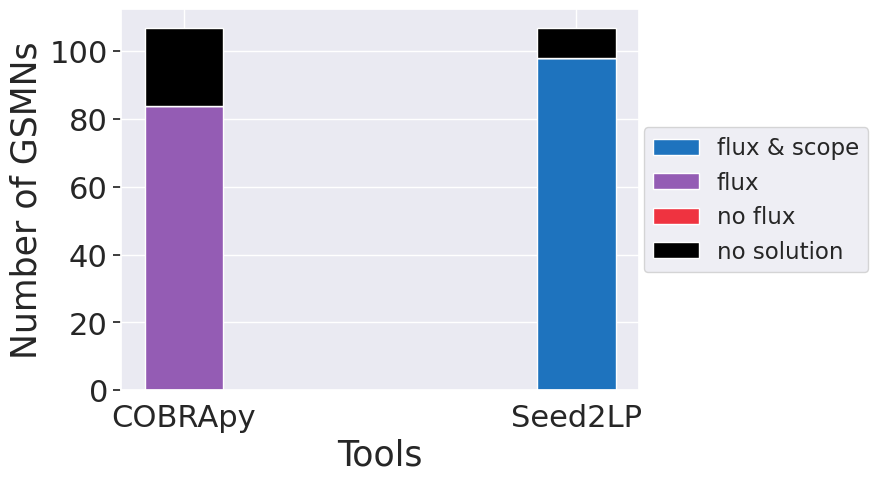

In [89]:
create_one_plot(s2lp_flux, ["Seed2LP", "COBRApy"], scope_s2lp, sub_scope_cobra_10)

## Scopes

### Up to 10 set of seeds

COBRApy  global mean:  33.69615534728883 	  Seed2LP global mean:  37.91048266268193


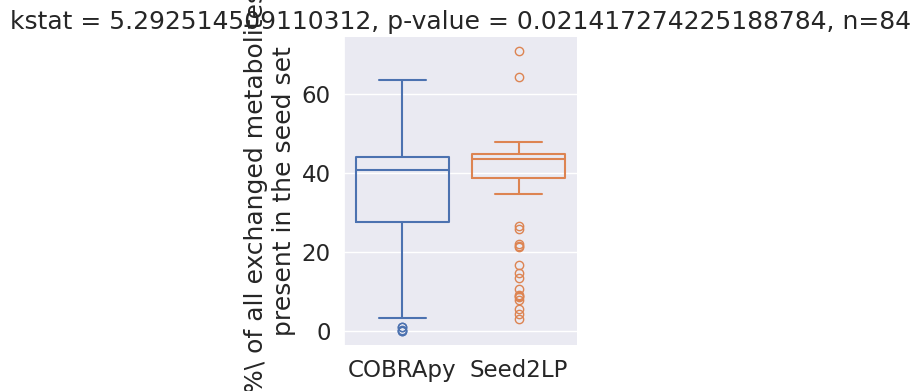

In [141]:
plot_compare(sub_scope_cobra_10, scope_s2lp, 'percentage_similar_exchange_into_seeds', ["COBRApy","Seed2LP"],
             y_label="%\ of all exchanged metabolites\npresent in the seed set")

COBRApy  global mean:  0.9238699547221468 	  Seed2LP global mean:  1.7882121790652552


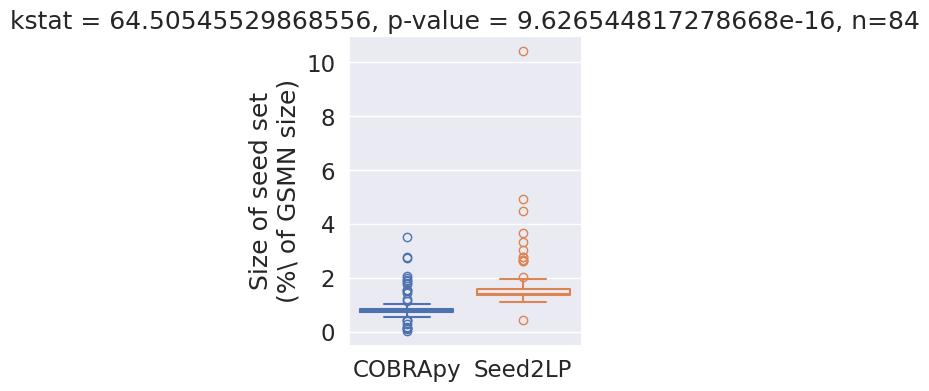

In [156]:
plot_compare(sub_data_size_cobra, data_size_s2lp, 'percent', ["COBRApy", "Seed2LP"], 
             y_label="Size of seed set\n(%\ of GSMN size)")

COBRApy  global mean:  16.130116827792556 	  Seed2LP global mean:  100.0


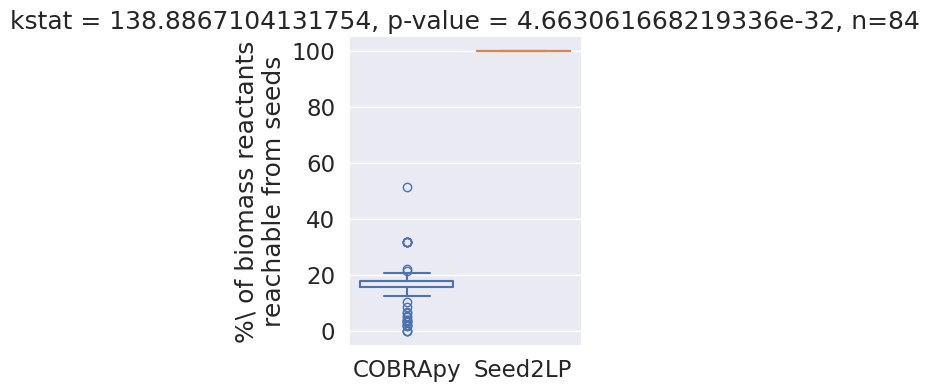

In [143]:
plot_compare(sub_scope_cobra_10, scope_s2lp, 'percentage_similar_biomass', ["COBRApy","Seed2LP"], 
             y_label="%\ of biomass reactants\nreachable from seeds")

COBRApy  global mean:  6.025116230670794 	  Seed2LP global mean:  65.22627846271938


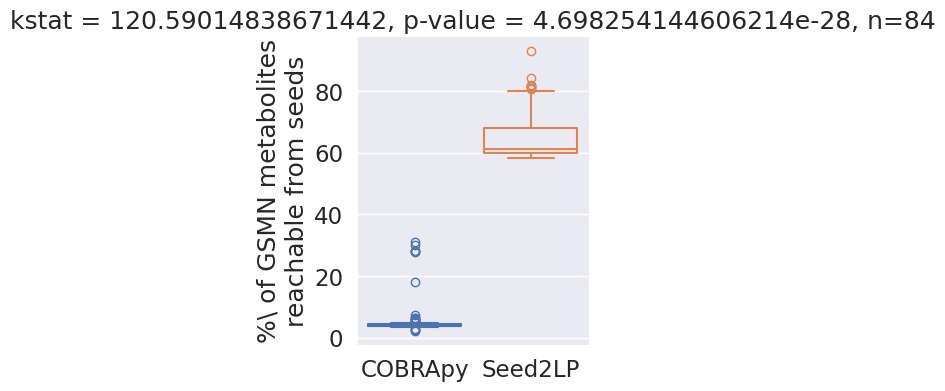

In [144]:
plot_compare( sub_scope_cobra_10, scope_s2lp, 'percentage_similar', ["COBRApy","Seed2LP"], 
             y_label="%\ of GSMN metabolites\nreachable from seeds")